# Agglomerative (Hierarchical) Clustering

## Table of Contents

### 1. What is Agglomerative Clustering?

### 2. Agglomerative Clustering in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for Agglomerative Clustering

## 1. What is Agglomerative Clustering?

A hierarchical clustering method that builds a tree (dendrogram) of clusters.

“Agglomerative” means bottom-up:

- Start with each point as its own cluster

- Iteratively merge the two closest clusters

- Repeat until all points are merged into one cluster or a desired number of clusters is reached

Result: a dendrogram (tree diagram showing cluster merges)

Goal: Understand **hierarchical relationships** between data points.

**Unlike K-Means, it does not require random initialization, so results are deterministic given the same parameters**


## 2. Agglomerative Clustering in Scikit-Learn

The name of the class for Agglomerative Clustering in Scikit-Learn
  **sklearn.cluster.AgglomerativeClustering**


## **AgglomerativeClustering Parameters Explained (scikit-learn)**

### **Most Important Parameters**

### `1. n_clusters`
-  The number of clusters to form. Determines how many groups the algorithm will merge the points into.  
- default=2
- If you also set `distance_threshold`, this parameter is ignored because merging is stopped based on distance rather than cluster count.  

### `2.metric`

Distance metric used to calculate similarity between points. Determines which points are “close” to each other.

**Common Options:**  
  - `euclidean` (default) → straight-line distance; most common for numeric features.  
  - `manhattan` → sum of absolute differences; robust to outliers.  
  - `cosine` → measures angle between vectors; useful for text embeddings   

### `3. linkage`

Determines how the distance between **clusters** is computed during merging  

**Options**  

  - `ward` (default) → merges clusters that **minimize the variance** of combined cluster; produces compact, round clusters. Only works with Euclidean distance

  - `complete` → distance = **maximum distance** between any two points across clusters. Produces **tight, well-separated clusters**

  - `average` → distance = **average of all pairwise distances** between points in the two clusters. Balanced behavior between single and complete linkage

Different linkages affect **cluster shape, size and sensitivity to noise**  




**Important rules and constraints:**
- If `linkage="ward"`, **only `"euclidean"` is allowed**  
  (because Ward’s method relies on variance minimization).

Choice of metric affects which points are considered “close” and thus which clusters are merged first  


### **Occasionally Used Parameters**

### `distance_threshold`

Stops merging clusters when the distance between clusters exceeds this threshold.

**Options:** float (default=None)  

- Useful when you want a **hierarchy** and do not know the number of clusters in advance

- Example: `distance_threshold=5` → any clusters separated by more than 5 units will **not merge**, creating more clusters automatically

- If set, `n_clusters` is ignored  


### `compute_full_tree`

Determines whether the full clustering tree is computed. Needed for dendrogram plotting.  

**Options**  (default=auto)
  - `auto` → computes full tree only when needed (e.g., small datasets or dendrogram)
  - `True` → always compute the full tree; useful for plotting dendrograms  
  - `False` → skips computing full tree to save memory and computation for large datasets

### Apply Agglomerative Clustering to a simple Dataset

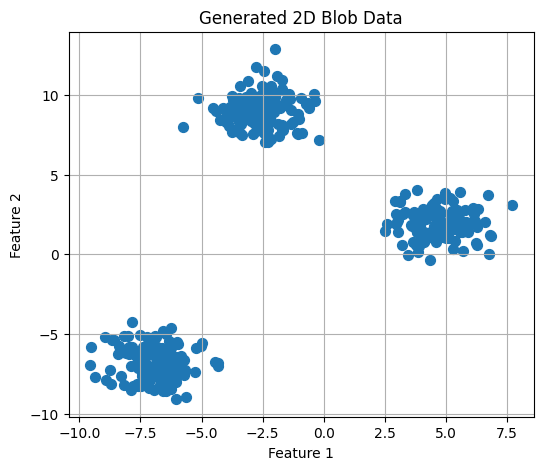

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import silhouette_score

# Generate 400 points in 2D, 3 clusters
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the raw data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

Silhouette Score: 0.8458787585795497


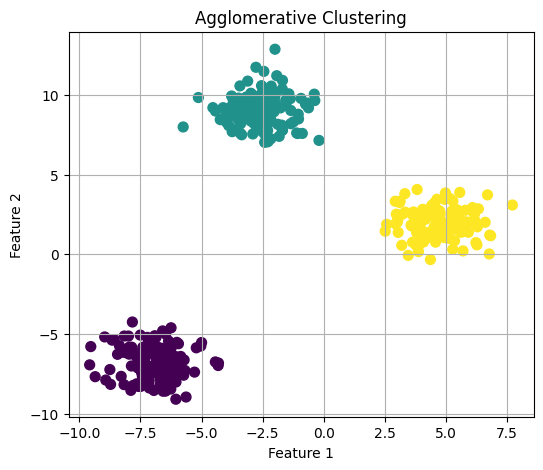

In [ ]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=3,       # we know 3 clusters exist
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
# Plot clustered data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")
plt.grid(True)
plt.show()

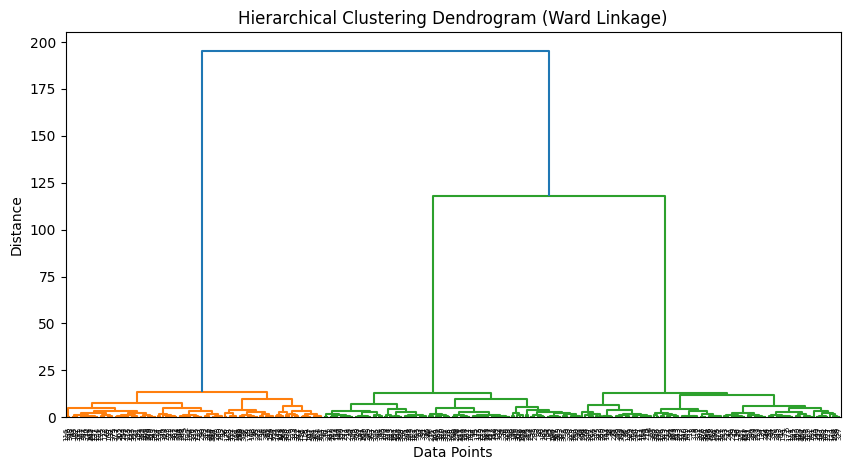

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#### How to Interpret the Dendrogram

- Each leaf → one data point

- Each merge → two clusters being combined

- The height of a merge → distance between clusters

#### Choosing the Number of Clusters

- Draw a horizontal line across the dendrogram

- Count how many vertical branches it cuts

### Rule of thumb:

Choose the cut where there is a large vertical gap
(big jump in distance before clusters merge)

## Important Considerations for Agglomerative Clustering

### When to Use Agglomerative Clustering

**- Does not require specifying K upfront:**  
Hierarchical clustering can build a full hierarchy of clusters and allows you to decide the number of clusters later by cutting the dendrogram at a chosen level.

**- Works well with small to medium datasets:**  
Because it computes distances between many pairs of points, it is more suitable when the dataset is not extremely large.

**- Useful for understanding data structure:**  
The dendrogram provides a visual explanation of how data points are grouped, making it useful for exploratory analysis.

**- Flexible cluster shapes (linkage):**  
Different linkage methods allow the algorithm to capture different types of cluster structures


### Limitations of Agglomerative Clustering

**- Computationally expensive:**  
Agglomerative clustering has higher time and memory complexity, making it impractical for very large datasets

**- Sensitive to noise and outliers:**  
Outliers can form their own clusters or distort the merging process

**- Early decisions cannot be undone:**  
Once two clusters are merged, the algorithm cannot reconsider that decision later, which may lead to suboptimal clusters

**- Results depend heavily on linkage choice:**  
Different linkage methods can produce very different clusterings, so parameter selection is critical

## Task 2A: Agglomerative Clustering

In this task, you will apply **Agglomerative Clustering** to `CC GENERAL` dataset and follow **the same methodology** used in the previous clustering lab

## **1. Exploratory Data Analysis (EDA)**

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 
from sklearn.datasets import make_blobs 
from sklearn.cluster import KMeans 
import csv 
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing

In [ ]:
"""
| Read the file
| Used lower case for all the column names
| Set the option to display all columns and displayed the first 4 rows of the data
| - BALANCE --> overall account balance.
| - PURCHASES --> total purchases.
| - ONEOFF_PURCHASES --> single large purchases.
| - INSTALLMENTS_PURCHASES --> purchases paid in installments.
| - CASH_ADVANCE --> cash withdrawn against credit.
| - PURCHASES_FREQUENCY --> how often purchases occur.
| - ONEOFF_PURCHASES_FREQUENCY --> frequency of one-off purchases.
| - PURCHASES_INSTALLMENTS_FREQUENCY --> frequency of installment purchases.
| - CASH_ADVANCE_FREQUENCY --> frequency of cash advances.
| - CASH_ADVANCE_TRX --> number of cash advance transactions.
| - PURCHASES_TRX --> number of purchase transactions.
| - CREDIT_LIMIT --> maximum credit available.
| - PAYMENTS --> total payments made.
| - MINIMUM_PAYMENTS --> minimum payments made.
| - PRC_FULL_PAYMENT --> proportion of full payments.
| - TENURE --> how long the customer has been with the bank.

"""
CC = pd.read_csv('CC GENERAL.csv', sep=',') 
CC.columns = CC.columns.str.lower()
pd.set_option('display.max_columns', None) 
CC.head(4)

,cust_id,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12


In [ ]:
"""
| min, max, mean, std, skewness, quantiles, etc. for numerical variables

"""
CC.describe()

,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [6]:
print(CC.isnull().sum())

cust_id                             0
balance                             0
balance_frequency                   0
purchases                           0
oneoff_purchases                    0
installments_purchases              0
cash_advance                        0
purchases_frequency                 0
oneoff_purchases_frequency          0
purchases_installments_frequency    0
cash_advance_frequency              0
cash_advance_trx                    0
purchases_trx                       0
credit_limit                        0
payments                            0
minimum_payments                    0
prc_full_payment                    0
tenure                              0
dtype: int64


In [7]:
"""
Fill missing values with mode for 'minimum_payments' and 'credit_limit'

"""
CC['minimum_payments'] = CC['minimum_payments'].fillna(
    CC['minimum_payments'].mode().iloc[0]
) 
CC['credit_limit'] = CC['credit_limit'].fillna(
    CC['credit_limit'].mode().iloc[0])



C:\Users\Alia\AppData\Local\Temp\ipykernel_37748\2280876355.py:4: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  CC.copy1 = CC.filter(items=['purchases', 'oneoff_purchases', 'installments_purchases', 'purchases_frequency', 'oneoff_purchases_frequency', 'purchases_installments_frequency','purchases_trx'])
C:\Users\Alia\AppData\Local\Temp\ipykernel_37748\2280876355.py:6: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  CC.copy2 = CC.filter(items=['cash_advance', 'cash_advance_frequency', 'cash_advance_trx', 'cash_advance_amount'])
C:\Users\Alia\AppData\Local\Temp\ipykernel_37748\2280876355.py:8: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  

                    balance  balance_frequency
balance            1.000000           0.322412
balance_frequency  0.322412           1.000000
                                  purchases  oneoff_purchases  \
purchases                          1.000000          0.916845   
oneoff_purchases                   0.916845          1.000000   
installments_purchases             0.679896          0.330622   
purchases_frequency                0.393017          0.264937   
oneoff_purchases_frequency         0.498430          0.524891   
purchases_installments_frequency   0.315567          0.127729   
purchases_trx                      0.689561          0.545523   

                                  installments_purchases  purchases_frequency  \
purchases                                       0.679896             0.393017   
oneoff_purchases                                0.330622             0.264937   
installments_purchases                          1.000000             0.442418   
purchases_freq

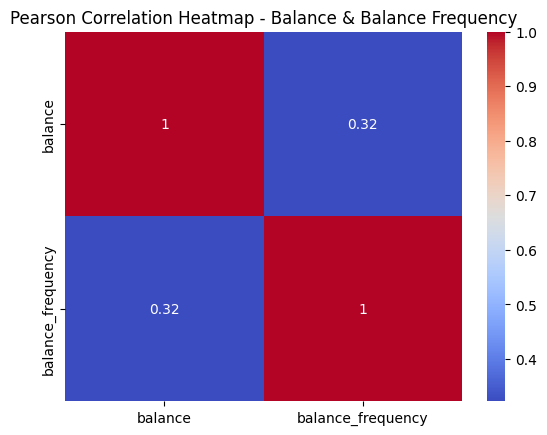

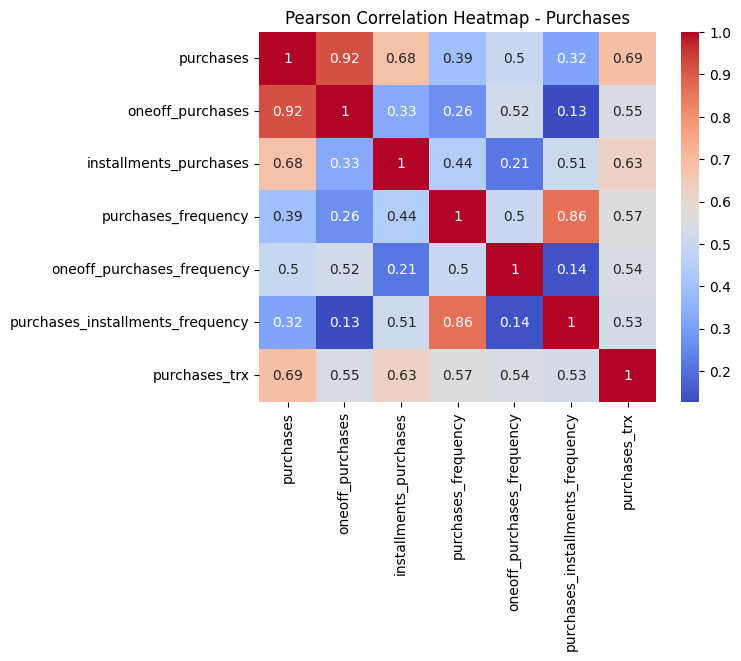

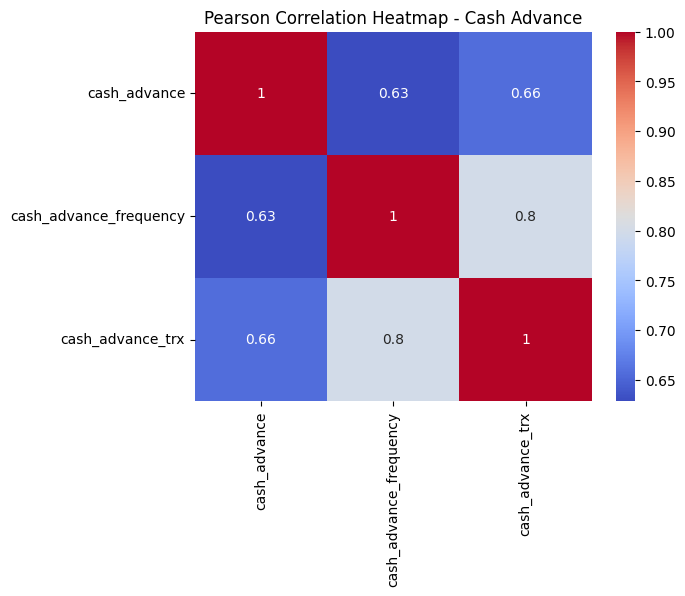

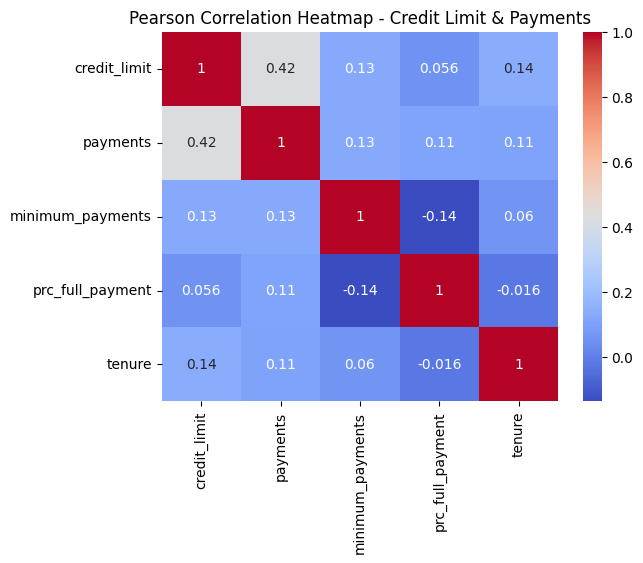

In [8]:

CC_copy = CC.filter(items=[
    'balance', 'balance_frequency'])

CC.copy1 = CC.filter(items=['purchases', 'oneoff_purchases', 'installments_purchases', 'purchases_frequency', 'oneoff_purchases_frequency', 'purchases_installments_frequency','purchases_trx'])

CC.copy2 = CC.filter(items=['cash_advance', 'cash_advance_frequency', 'cash_advance_trx', 'cash_advance_amount'])

CC.copy3 = CC.filter(items=['credit_limit', 'payments', 'minimum_payments', 'prc_full_payment', 'tenure'])

pearson_cor1 = CC_copy.corr(method='pearson')
pearson_cor2 = CC.copy1.corr(method='pearson')
pearson_cor3 = CC.copy2.corr(method='pearson')
pearson_cor4 = CC.copy3.corr(method='pearson')

print(pearson_cor1)
print(pearson_cor2)
print(pearson_cor3)
print(pearson_cor4)

sns.heatmap(pearson_cor1, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap - Balance & Balance Frequency")
plt.show()
sns.heatmap(pearson_cor2, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap - Purchases")
plt.show()
sns.heatmap(pearson_cor3, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap - Cash Advance")
plt.show()
sns.heatmap(pearson_cor4, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap - Credit Limit & Payments")
plt.show()

Q1: 128.282, Q3: 2054.140, IQR: 1925.858


<Axes: xlabel='balance'>

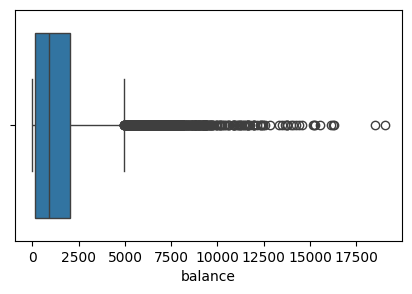

In [9]:
""" 
| Identifying Outliers in Balance

"""
Q1 = CC['balance'].quantile(0.25)
Q3 = CC['balance'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['balance'])

Q1: 0.889, Q3: 1.000, IQR: 0.111


<Axes: xlabel='balance_frequency'>

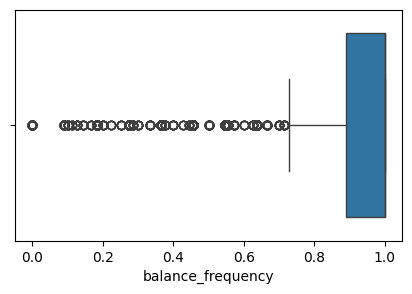

In [ ]:
""" 
| Identifying Outliers in Balance Frequency

"""
Q1 = CC['balance_frequency'].quantile(0.25)
Q3 = CC['balance_frequency'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['balance_frequency'])

Q1: 39.635, Q3: 1110.130, IQR: 1070.495


<Axes: xlabel='purchases'>

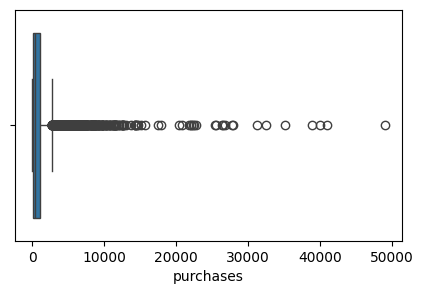

In [11]:
""" 
| Identifying Outliers in Purchases

"""
Q1 = CC['purchases'].quantile(0.25)
Q3 = CC['purchases'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['purchases'])

Q1: 0.000, Q3: 577.405, IQR: 577.405


<Axes: xlabel='oneoff_purchases'>

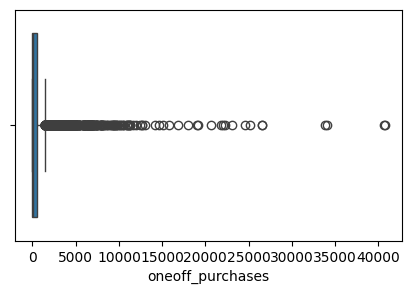

In [ ]:
""" 
| Identifying Outliers in One-Off Purchases

"""
Q1 = CC['oneoff_purchases'].quantile(0.25)
Q3 = CC['oneoff_purchases'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['oneoff_purchases'])

Q1: 0.000, Q3: 468.637, IQR: 468.637


<Axes: xlabel='installments_purchases'>

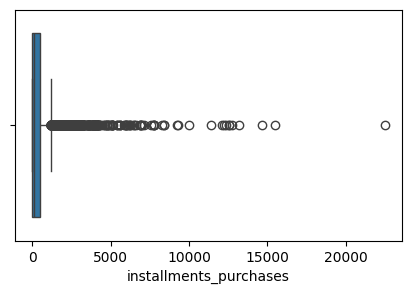

In [14]:
""" 
| Identifying Outliers in INSTALLMENTS_PURCHASES

"""
Q1 = CC['installments_purchases'].quantile(0.25)
Q3 = CC['installments_purchases'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['installments_purchases'])

Q1: 0.000, Q3: 1113.821, IQR: 1113.821


<Axes: xlabel='cash_advance'>

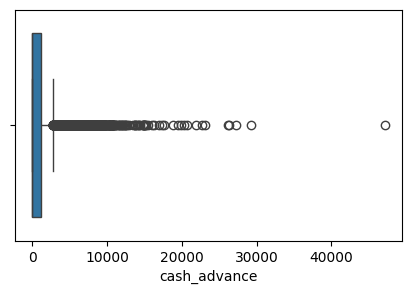

In [15]:
""" 
| Identifying Outliers in CASH_ADVANCE

"""
Q1 = CC['cash_advance'].quantile(0.25)
Q3 = CC['cash_advance'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['cash_advance'])

Q1: 0.000, Q3: 0.300, IQR: 0.300


<Axes: xlabel='oneoff_purchases_frequency'>

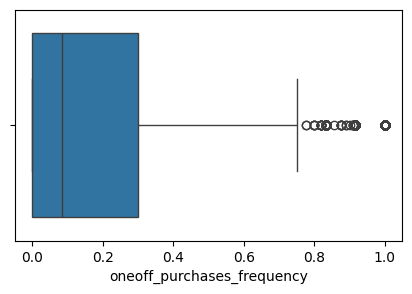

In [16]:
""" 
| Identifying Outliers in ONEOFF_PURCHASES_FREQUENCY

"""
Q1 = CC['oneoff_purchases_frequency'].quantile(0.25)
Q3 = CC['oneoff_purchases_frequency'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['oneoff_purchases_frequency'])

Q1: 0.000, Q3: 0.750, IQR: 0.750


<Axes: xlabel='purchases_installments_frequency'>

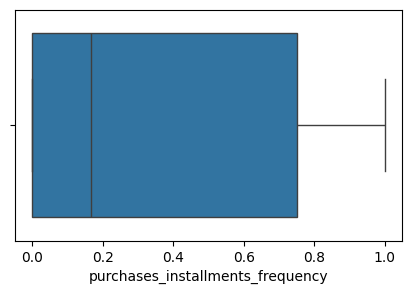

In [17]:
""" 
| Identifying Outliers in PURCHASES_INSTALLMENTS_FREQUENCY

"""
Q1 = CC['purchases_installments_frequency'].quantile(0.25)
Q3 = CC['purchases_installments_frequency'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['purchases_installments_frequency'])

Q1: 0.000, Q3: 0.222, IQR: 0.222


<Axes: xlabel='cash_advance_frequency'>

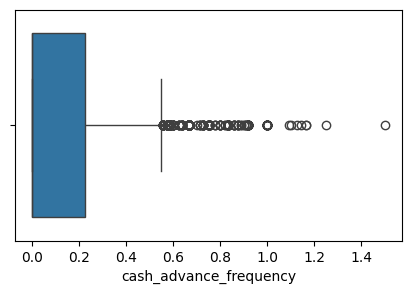

In [18]:
""" 
| Identifying Outliers in CASH_ADVANCE_FREQUENCY

"""
Q1 = CC['cash_advance_frequency'].quantile(0.25)
Q3 = CC['cash_advance_frequency'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['cash_advance_frequency'])

Q1: 0.000, Q3: 4.000, IQR: 4.000


<Axes: xlabel='cash_advance_trx'>

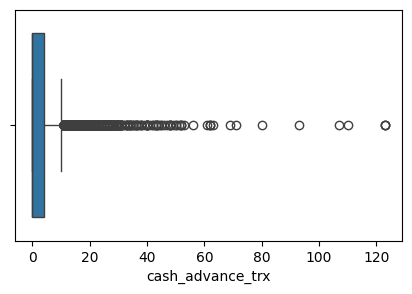

In [19]:
""" 
| Identifying Outliers in CASH_ADVANCE_TRX

"""
Q1 = CC['cash_advance_trx'].quantile(0.25)
Q3 = CC['cash_advance_trx'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['cash_advance_trx'])

Q1: 1.000, Q3: 17.000, IQR: 16.000


<Axes: xlabel='purchases_trx'>

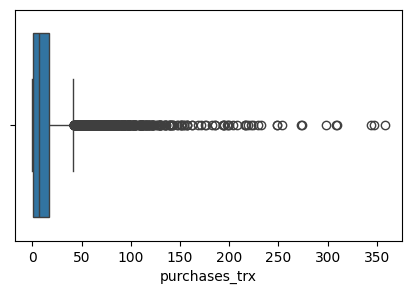

In [20]:
""" 
| Identifying Outliers in PURCHASES_TRX

"""
Q1 = CC['purchases_trx'].quantile(0.25)
Q3 = CC['purchases_trx'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['purchases_trx'])

Q1: 1600.000, Q3: 6500.000, IQR: 4900.000


<Axes: xlabel='credit_limit'>

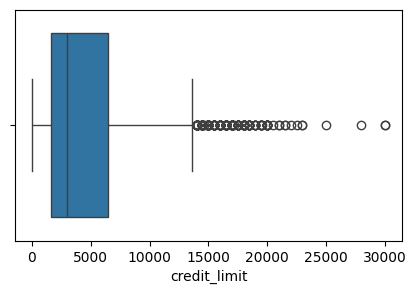

In [21]:
""" 
| Identifying Outliers in CREDIT_LIMIT

"""
Q1 = CC['credit_limit'].quantile(0.25)
Q3 = CC['credit_limit'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['credit_limit'])

Q1: 383.276, Q3: 1901.134, IQR: 1517.858


<Axes: xlabel='payments'>

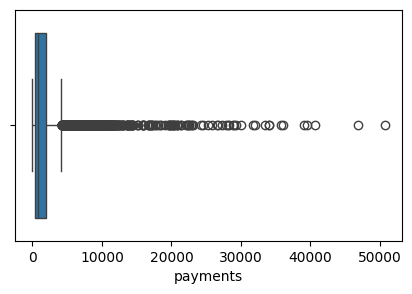

In [22]:
""" 
| Identifying Outliers in PAYMENTS

"""
Q1 = CC['payments'].quantile(0.25)
Q3 = CC['payments'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['payments'])

Q1: 170.858, Q3: 788.714, IQR: 617.856


<Axes: xlabel='minimum_payments'>

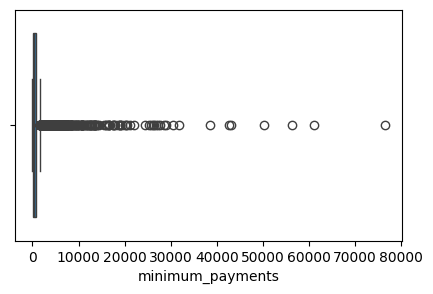

In [23]:
""" 
| Identifying Outliers in MINIMUM_PAYMENTS

"""
Q1 = CC['minimum_payments'].quantile(0.25)
Q3 = CC['minimum_payments'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['minimum_payments'])

Q1: 0.000, Q3: 0.143, IQR: 0.143


<Axes: xlabel='prc_full_payment'>

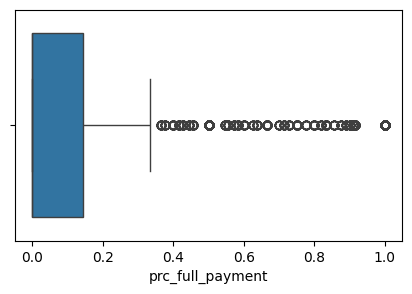

In [24]:
""" 
| Identifying Outliers in PRC_FULL_PAYMENT

"""
Q1 = CC['prc_full_payment'].quantile(0.25)
Q3 = CC['prc_full_payment'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['prc_full_payment'])

Q1: 12.000, Q3: 12.000, IQR: 0.000


<Axes: xlabel='tenure'>

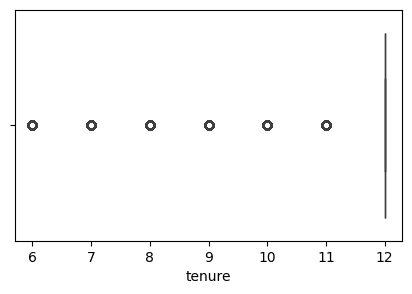

In [25]:
""" 
| Identifying Outliers in TENURE

"""
Q1 = CC['tenure'].quantile(0.25)
Q3 = CC['tenure'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=CC['tenure'])

## **2. Data Preparation**

In [26]:
"""
| Instead of dropping columns in the original dataset, I will create a copy of the dataset and select only the relevant numerical columns for further analysis. 
| I have chosen the following columns based on what I think is relevant and dropped the duration column due to stated in the description that 
    it should be discarded if a realitic predictive model is needed. Nor is it relevant to know the type of contact, the day and month and the poutcome of the previous campaign.

"""
CC_copy = CC.filter(items=[
    'balance', 'purchases', 'oneoff_purchases', 'installments_purchases', 'purchases_frequency', 'oneoff_purchases_frequency', 'purchases_installments_frequency','purchases_trx', 'cash_advance', 'cash_advance_frequency', 'cash_advance_trx', 'cash_advance_amount', 'credit_limit', 'payments', 'minimum_payments', 'prc_full_payment', 'tenure'])
CC_copy.head(4)

,balance,purchases,oneoff_purchases,installments_purchases,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,purchases_trx,cash_advance,cash_advance_frequency,cash_advance_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
0,40.900749,95.40,0.00,95.4,0.166667,0.000000,0.083333,2,0.000000,0.000000,0,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.00,0.00,0.0,0.000000,0.000000,0.000000,0,6442.945483,0.250000,4,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,773.17,773.17,0.0,1.000000,1.000000,0.000000,12,0.000000,0.000000,0,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,1499.00,1499.00,0.0,0.083333,0.083333,0.000000,1,205.788017,0.083333,1,7500.0,0.000000,299.351881,0.000000,12


In [28]:
""" 
| Encoding Categorical Variables using LabelEncoder as it does not expand the dataset 

"""
encoder = LabelEncoder()
CC_copy['balance'] = encoder.fit_transform(CC_copy['balance'])
CC_copy['purchases'] = encoder.fit_transform(CC_copy['purchases'])
CC_copy['oneoff_purchases'] = encoder.fit_transform(CC_copy['oneoff_purchases'])
CC_copy['installments_purchases'] = encoder.fit_transform(CC_copy['installments_purchases'])
CC_copy['purchases_frequency'] = encoder.fit_transform(CC_copy['purchases_frequency'])
CC_copy['oneoff_purchases_frequency'] = encoder.fit_transform(CC_copy['oneoff_purchases_frequency'])
CC_copy['purchases_installments_frequency'] = encoder.fit_transform(CC_copy['purchases_installments_frequency'])
CC_copy['purchases_trx'] = encoder.fit_transform(CC_copy['purchases_trx'])
CC_copy['cash_advance'] = encoder.fit_transform(CC_copy['cash_advance'])
CC_copy['cash_advance_frequency'] = encoder.fit_transform(CC_copy['cash_advance_frequency'])
CC_copy['cash_advance_trx'] = encoder.fit_transform(CC_copy['cash_advance_trx'])
CC_copy['credit_limit'] = encoder.fit_transform(CC_copy['credit_limit'])
CC_copy['payments'] = encoder.fit_transform(CC_copy['payments'])    
CC_copy['minimum_payments'] = encoder.fit_transform(CC_copy['minimum_payments'])
CC_copy['prc_full_payment'] = encoder.fit_transform(CC_copy['prc_full_payment'])
CC_copy['tenure'] = encoder.fit_transform(CC_copy['tenure'])
CC_copy.head(4)

,balance,purchases,oneoff_purchases,installments_purchases,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,purchases_trx,cash_advance,cash_advance_frequency,cash_advance_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
0,1189,521,0,515,7,0,1,2,0,0,0,13,812,1394,0,6
1,7535,0,0,0,0,0,0,0,4087,11,4,123,7879,6979,10,6
2,7019,3295,2173,0,46,46,0,12,0,0,0,130,3328,5893,0,6
3,6133,4529,3046,0,1,1,0,1,675,1,1,130,0,4228,0,6


In [29]:
""" 
| Scaling Numerical Variables using RobustScaler to handle outliers effectively as we didn't handle outliers above.

"""
scaler = preprocessing.RobustScaler()
CC_scaled = scaler.fit_transform(CC_copy)
CC_scaled = pd.DataFrame(CC_scaled, columns=CC_copy.columns)
CC_scaled.head(4)

,balance,purchases,oneoff_purchases,installments_purchases,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,purchases_trx,cash_advance,cash_advance_frequency,cash_advance_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
0,-0.716616,-0.369999,-0.067149,0.020559,-0.363636,-0.071429,-0.171429,-0.3125,0.000000,0.0,0.00,-0.488636,-0.765113,-0.681168,0.000000,0.0
1,0.701643,-0.505800,-0.067149,-0.200021,-0.522727,-0.071429,-0.200000,-0.4375,1.960427,1.1,1.00,0.761364,0.814281,0.661219,1.666667,0.0
2,0.586322,0.353056,1.119148,-0.200021,0.522727,3.214286,-0.200000,0.3125,0.000000,0.0,0.00,0.840909,-0.202816,0.400192,0.000000,0.0
3,0.388312,0.674704,1.595742,-0.200021,-0.500000,0.000000,-0.200000,-0.3750,0.323780,0.1,0.25,0.840909,-0.946586,0.000000,0.000000,0.0


## **3. Apply Agglomerative Clustering**

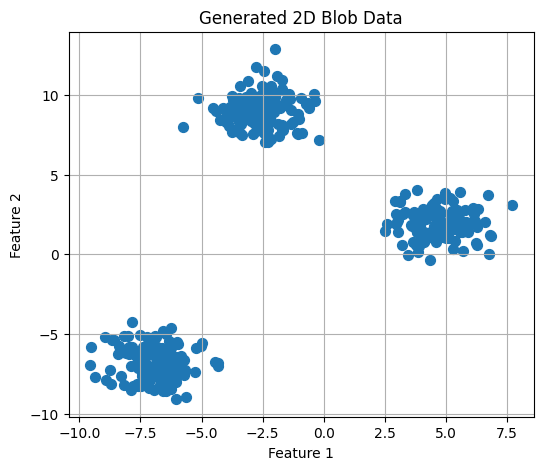

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import silhouette_score


X = CC_scaled.values
# Generate 400 points in 2D, 3 clusters
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the raw data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

Silhouette Score: 0.3656724540050488


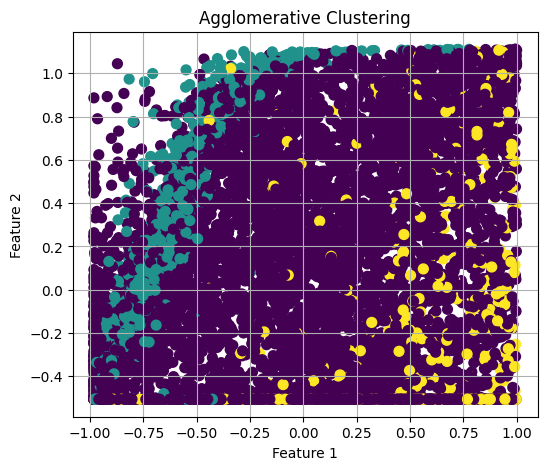

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score



X = CC_scaled.values

agg = AgglomerativeClustering(
    n_clusters=3,       # we know 3 clusters exist
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
# Plot clustered data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")
plt.grid(True)
plt.show()


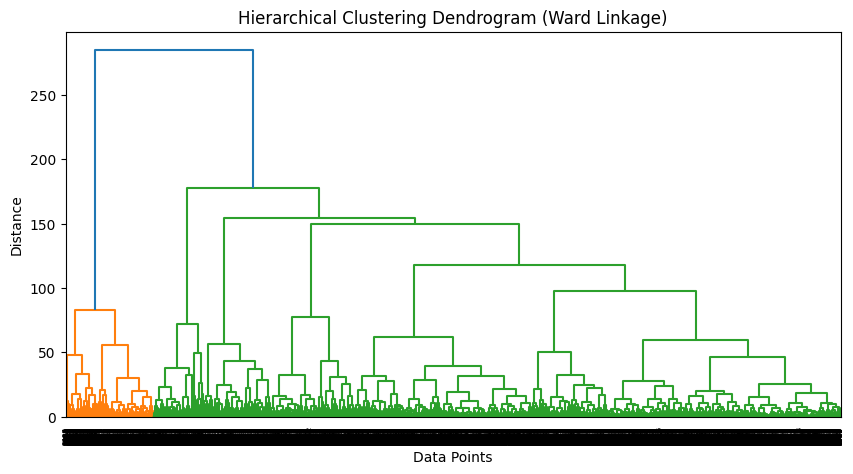

In [35]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()